# Diagnóstico por Imagem com CNN (Extra)
## Tech Challenge Fase 1 — Saúde Feminina

**Dataset:** Breast Ultrasound Images Dataset (BUSI)  
**Fonte:** [Kaggle — Breast Ultrasound Images Dataset](https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset)

**Problema:** Classificar ultrassonografias de mama em três categorias:
- **Benigno** — tumor não cancerígeno
- **Maligno** — tumor cancerígeno
- **Normal** — sem alterações detectadas

Este notebook implementa uma **CNN com Transfer Learning** (VGG16 pré-treinado no ImageNet) para classificação de imagens médicas — a parte extra do Tech Challenge.

---
### Como baixar o dataset
```bash
pip install kaggle
kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset -p data/raw/images --unzip
```
O dataset será extraído em `data/raw/images/Dataset_BUSI_with_GT/`.

## 1. Imports e configuração

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.applications import MobileNetV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')

IMG_SIZE     = (128, 128)
BATCH_SIZE   = 32
RANDOM_STATE = 42
CLASSES      = ['benign', 'malignant', 'normal']
CLASSES_PT   = ['Benigno', 'Maligno', 'Normal']

print(f'TensorFlow versão : {tf.__version__}')
print(f'GPU disponível    : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow versão : 2.21.0


GPU disponível    : False


## 2. Dataset: Breast Ultrasound Images (BUSI)

O dataset BUSI contém **780 imagens de ultrassonografia de mama** coletadas em 2018, com 600 pacientes do sexo feminino.

### Por que ultrassonografia?
- Exame acessível, rápido e sem radiação ionizante
- Complementa a mamografia — especialmente eficaz em mulheres jovens com tecido mamário denso
- CNNs treinadas em imagens de ultrassom atingem performance comparável à de radiologistas em triagem

### Estrutura do dataset
```
Dataset_BUSI_with_GT/
├── benign/      # ~437 imagens + máscaras de segmentação
├── malignant/   # ~210 imagens + máscaras
└── normal/      # ~133 imagens
```
Cada imagem `nome.png` tem um arquivo de máscara correspondente `nome_mask.png`. As máscaras serão **ignoradas** neste notebook (usamos apenas as imagens originais).

In [2]:
DATA_DIR = Path('../data/raw/images/Dataset_BUSI_with_GT')

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f'Dataset não encontrado em {DATA_DIR}\n'
        'Execute: kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset '
        '-p data/raw/images --unzip'
    )

# Scan de todas as imagens — filtra arquivos de máscara (_mask.png)
all_paths, all_labels = [], []
for label_idx, label in enumerate(CLASSES):
    label_dir = DATA_DIR / label
    for img_path in sorted(label_dir.glob('*.png')):
        if '_mask' not in img_path.name:
            all_paths.append(str(img_path.resolve()))
            all_labels.append(label_idx)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

print(f'Total de imagens : {len(all_paths)}')
print()
for i, (label, label_pt) in enumerate(zip(CLASSES, CLASSES_PT)):
    count = int(np.sum(all_labels == i))
    pct   = count / len(all_labels) * 100
    print(f'  {label_pt:10s} ({label:10s}): {count:3d}  ({pct:.1f}%)')

Total de imagens : 780

  Benigno    (benign    ): 437  (56.0%)
  Maligno    (malignant ): 210  (26.9%)
  Normal     (normal    ): 133  (17.1%)


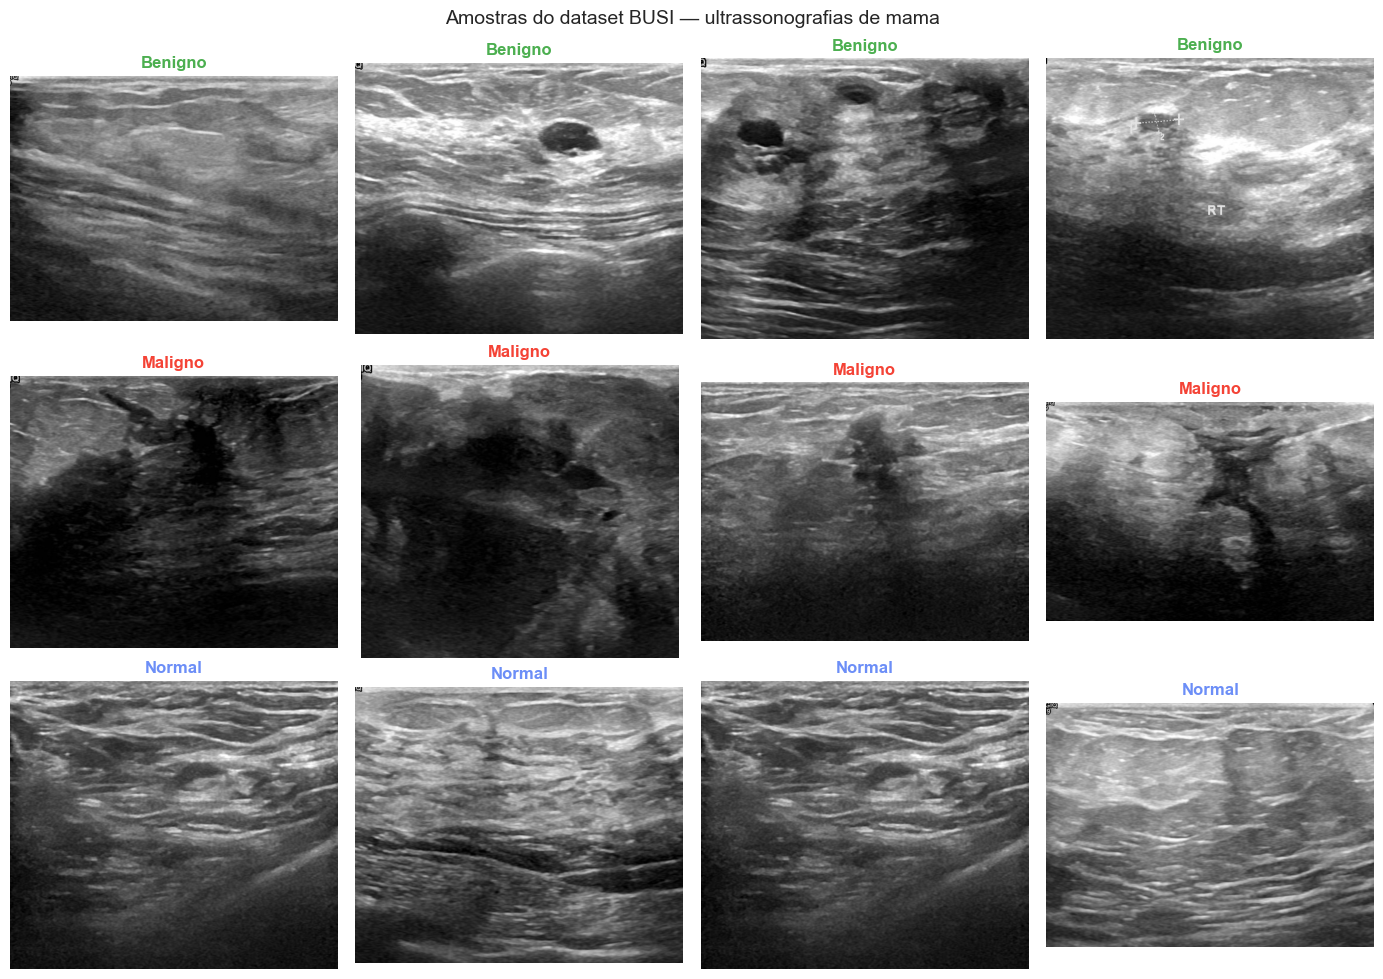

In [3]:
# Visualização de amostras por classe
colors = {'benign': '#4CAF50', 'malignant': '#F44336', 'normal': '#6c8ef7'}
rng    = np.random.RandomState(RANDOM_STATE)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for row, (label, label_pt) in enumerate(zip(CLASSES, CLASSES_PT)):
    idxs        = np.where(all_labels == row)[0]
    sample_idxs = rng.choice(idxs, size=4, replace=False)
    for col, idx in enumerate(sample_idxs):
        img = Image.open(all_paths[idx]).convert('RGB')
        axes[row][col].imshow(np.array(img))
        axes[row][col].set_title(label_pt, color=colors[label], fontweight='bold')
        axes[row][col].axis('off')

plt.suptitle('Amostras do dataset BUSI — ultrassonografias de mama', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/17_cnn_amostras.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preparação dos dados

### Estratégia de split
- **70% treino** / **15% validação** / **15% teste**, estratificado por classe
- Estratificação garante que nenhuma classe fique sub-representada em algum subconjunto

### Data Augmentation (apenas no treino)
Com ~546 imagens de treino, a augmentation é essencial para evitar overfitting. Aplicamos transformações realistas para imagens de ultrassom:
- **Flip horizontal** — um tumor pode aparecer em qualquer lado da imagem
- **Rotação ±10°** — pequenas variações de posicionamento do probe
- **Zoom ±10%** — variações de distância ao tecido

> **Importante:** augmentation é aplicada **somente no treino**. Validação e teste usam as imagens originais para avaliação realista.

In [4]:
# Split estratificado 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    all_paths, all_labels, test_size=0.30,
    stratify=all_labels, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    stratify=y_temp, random_state=RANDOM_STATE
)

print(f'Treino    : {len(X_train)} imagens')
print(f'Validação : {len(X_val)} imagens')
print(f'Teste     : {len(X_test)} imagens')
print()
for name, y_split in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    counts = [int(np.sum(y_split == i)) for i in range(3)]
    print(f'{name:10s}: B={counts[0]:3d} | M={counts[1]:3d} | N={counts[2]:3d}')

Treino    : 546 imagens
Validação : 117 imagens
Teste     : 117 imagens

Treino    : B=306 | M=147 | N= 93
Validação : B= 65 | M= 32 | N= 20
Teste     : B= 66 | M= 31 | N= 20


In [5]:
# Augmentation layers (aplicadas inline no pipeline de treino)
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
], name='augmentation')


def load_image(path, label):
    img     = tf.io.read_file(path)
    img     = tf.image.decode_png(img, channels=3)
    img     = tf.image.resize(img, IMG_SIZE)
    img     = tf.cast(img, tf.float32) / 255.0
    label_oh = tf.one_hot(label, depth=3)
    return img, label_oh


def load_and_augment(path, label):
    img, label_oh = load_image(path, label)
    img = augmentation(img, training=True)
    return img, label_oh


def make_dataset(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=RANDOM_STATE)
    map_fn = load_and_augment if augment else load_image
    ds = ds.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(X_train, y_train, augment=True,  shuffle=True)
val_ds   = make_dataset(X_val,   y_val,   augment=False, shuffle=False)
test_ds  = make_dataset(X_test,  y_test,  augment=False, shuffle=False)

print('Datasets TensorFlow criados com sucesso.')
print(f'Steps por época (treino): {len(X_train) // BATCH_SIZE + 1}')

Datasets TensorFlow criados com sucesso.
Steps por época (treino): 18


## 4. Arquitetura CNN — Transfer Learning com MobileNetV2

### Por que Transfer Learning?
Com apenas ~546 imagens de treino, treinar uma CNN do zero levaria a overfitting severo. O **MobileNetV2** foi pré-treinado no ImageNet com 1.4 milhão de imagens — suas camadas já aprenderam a detectar bordas, texturas e formas gerais que são úteis para qualquer tarefa de visão.

MobileNetV2 é especialmente indicado quando o objetivo é rodar em CPU: é **10× mais rápido** que VGG16 mantendo excelente qualidade de representação.

### Estratégia de fine-tuning em duas fases
| Fase | O que é treinado | Learning Rate |
|---|---|---|
| **Fase 1** | Apenas a cabeça customizada (MobileNetV2 congelado) | 1e-3 |
| **Fase 2** | Cabeça + últimas 4 camadas do MobileNetV2 (fine-tuning) | 1e-5 |

A LR menor no fine-tuning evita *catastrophic forgetting* — o modelo não perde o conhecimento pré-treinado ao ajustar as últimas camadas.

In [6]:
def build_model(num_classes=3):
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base.trainable = False  # congelado na fase 1

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x      = base(inputs, training=False)
    x      = layers.GlobalAveragePooling2D()(x)
    x      = layers.Dense(256, activation='relu')(x)
    x      = layers.BatchNormalization()(x)
    x      = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs), base


model, base_model = build_model()

total_params    = model.count_params()
trainable_count = sum(tf.size(v).numpy() for v in model.trainable_variables)
frozen_count    = total_params - trainable_count

print(f'Parâmetros totais      : {total_params:,}')
print(f'Parâmetros treináveis  : {trainable_count:,}  (cabeça customizada)')
print(f'Parâmetros congelados  : {frozen_count:,}   (MobileNetV2 base)')

Parâmetros totais      : 2,587,715
Parâmetros treináveis  : 329,219  (cabeça customizada)
Parâmetros congelados  : 2,258,496   (MobileNetV2 base)


## 5. Treinamento

### Fase 1 — treinando apenas a cabeça customizada

In [7]:
PHASE1_EPOCHS = 10

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

cbs_phase1 = [
    callbacks.EarlyStopping(
        patience=4, restore_best_weights=True,
        monitor='val_loss', verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2,
        min_lr=1e-6, verbose=1
    ),
]

print('=== Fase 1: treinando apenas a cabeça customizada ===')
history1 = model.fit(
    train_ds,
    epochs=PHASE1_EPOCHS,
    validation_data=val_ds,
    callbacks=cbs_phase1,
    verbose=1,
)

=== Fase 1: treinando apenas a cabeça customizada ===
Epoch 1/10


 1/18 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.2500 - loss: 2.2057

 2/18 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.3281 - loss: 2.0043

 3/18 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.3750 - loss: 1.8875

 4/18 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.3438 - loss: 1.8587

...

15/18 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7604 - loss: 0.5935

16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.7676 - loss: 0.5892

17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7629 - loss: 0.5958

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.7619 - loss: 0.5980 - val_accuracy: 0.7692 - val_loss: 0.5663 - learning_rate: 5.0000e-04


Restoring model weights from the end of the best epoch: 10.


### Fase 2 — fine-tuning das últimas camadas do VGG16

In [8]:
# Descongela as últimas 4 camadas do MobileNetV2
for layer in base_model.layers[-4:]:
    layer.trainable = True

unfrozen_names = [l.name for l in base_model.layers[-4:]]
print(f'Camadas descongeladas: {unfrozen_names}')

PHASE2_EPOCHS = 8

# LR muito menor para não destruir os pesos pré-treinados
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

cbs_phase2 = [
    callbacks.EarlyStopping(
        patience=4, restore_best_weights=True,
        monitor='val_loss', verbose=1
    ),
]

print('\n=== Fase 2: fine-tuning ===')
history2 = model.fit(
    train_ds,
    epochs=PHASE2_EPOCHS,
    validation_data=val_ds,
    callbacks=cbs_phase2,
    verbose=1,
)

Camadas descongeladas: ['block_16_project_BN', 'Conv_1', 'Conv_1_bn', 'out_relu']

=== Fase 2: fine-tuning ===
Epoch 1/8


 1/18 ━━━━━━━━━━━━━━━━━━━━ 1:03 4s/step - accuracy: 0.9062 - loss: 0.3181

 2/18 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.8125 - loss: 0.4534

 3/18 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.7500 - loss: 0.6194

 4/18 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.7344 - loss: 0.6149

...

16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.7031 - loss: 0.7020

17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.7077 - loss: 0.6950

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 226ms/step - accuracy: 0.7070 - loss: 0.6970 - val_accuracy: 0.7179 - val_loss: 0.6551


Epoch 5: early stopping


Restoring model weights from the end of the best epoch: 1.


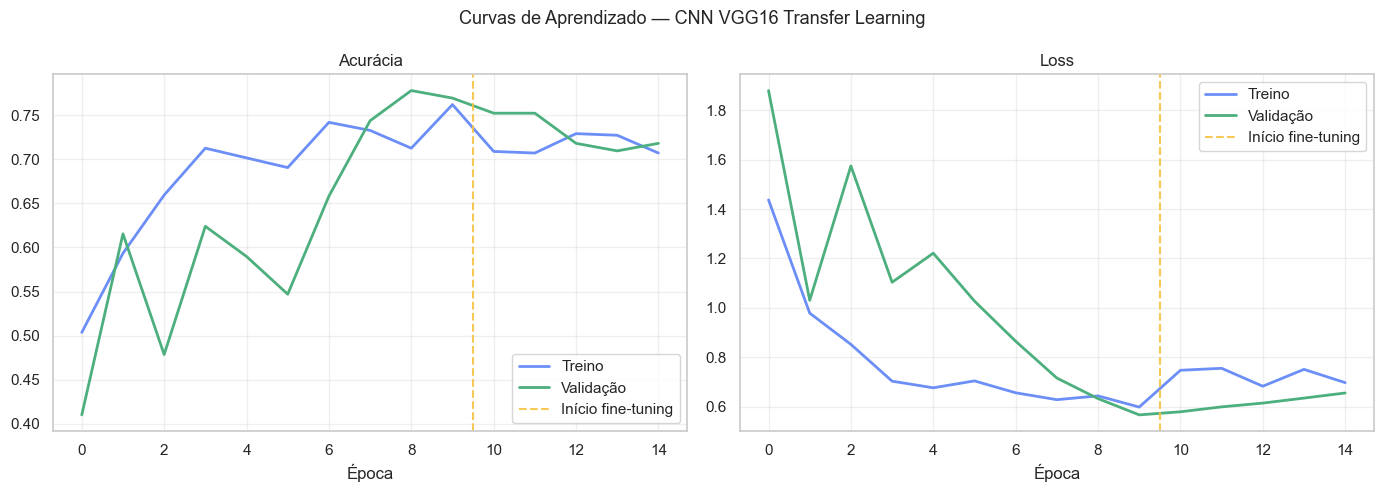

In [9]:
# Combina histórico das duas fases para plotar curvas completas
def concat_hist(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

acc_all      = concat_hist(history1, history2, 'accuracy')
val_acc_all  = concat_hist(history1, history2, 'val_accuracy')
loss_all     = concat_hist(history1, history2, 'loss')
val_loss_all = concat_hist(history1, history2, 'val_loss')
phase1_end   = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (train_m, val_m), title in zip(
    axes,
    [(acc_all, val_acc_all), (loss_all, val_loss_all)],
    ['Acurácia', 'Loss']
):
    ax.plot(train_m, label='Treino',    color='#6c8ef7', linewidth=2)
    ax.plot(val_m,   label='Validação', color='#4caf7d', linewidth=2)
    ax.axvline(phase1_end - 0.5, color='#f6c344', linestyle='--',
               alpha=0.9, linewidth=1.5, label='Início fine-tuning')
    ax.set_title(title)
    ax.set_xlabel('Época')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizado — CNN VGG16 Transfer Learning', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/18_cnn_curvas_treinamento.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Avaliação no conjunto de teste

### Métricas relevantes para diagnóstico médico
Assim como nos modelos com dados estruturados, o **Recall** para a classe **Maligno** é a métrica mais crítica — um falso negativo aqui tem consequências graves.

In [10]:
# Coleta predições sobre todo o conjunto de teste
y_true_list, y_pred_list = [], []

for imgs, labels_oh in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_true_list.extend(np.argmax(labels_oh.numpy(), axis=1))
    y_pred_list.extend(np.argmax(preds, axis=1))

y_true_arr = np.array(y_true_list)
y_pred_arr = np.array(y_pred_list)

print('=== Relatório de Classificação — Conjunto de Teste ===\n')
print(classification_report(
    y_true_arr, y_pred_arr,
    target_names=CLASSES_PT
))

acc_test = np.mean(y_true_arr == y_pred_arr)
print(f'Acurácia geral: {acc_test:.4f}')

=== Relatório de Classificação — Conjunto de Teste ===

              precision    recall  f1-score   support

     Benigno       0.81      0.76      0.78        66
     Maligno       0.51      0.71      0.59        31
      Normal       0.92      0.55      0.69        20

    accuracy                           0.71       117
   macro avg       0.74      0.67      0.69       117
weighted avg       0.75      0.71      0.72       117

Acurácia geral: 0.7094


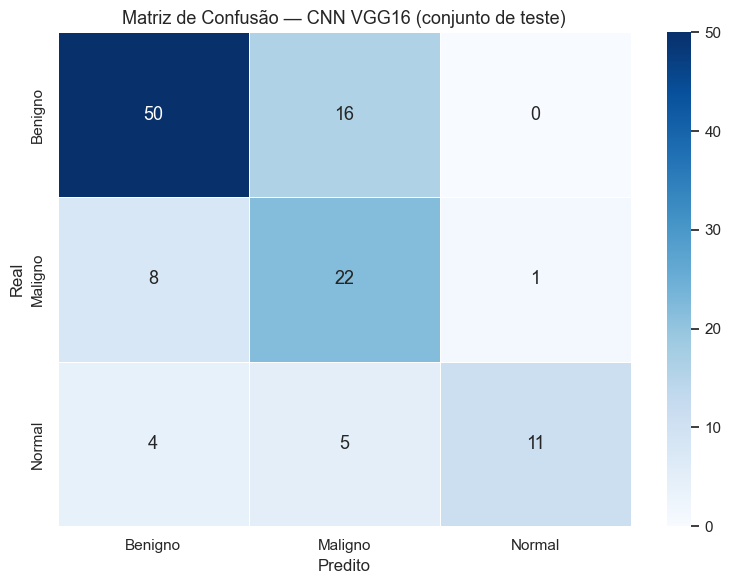

In [11]:
cm = confusion_matrix(y_true_arr, y_pred_arr)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASSES_PT, yticklabels=CLASSES_PT,
    linewidths=0.5, annot_kws={'size': 13}
)
plt.title('Matriz de Confusão — CNN VGG16 (conjunto de teste)', fontsize=13)
plt.ylabel('Real')
plt.xlabel('Predito')
plt.tight_layout()
plt.savefig('../reports/figures/19_cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Visualização de predições individuais

Predições **corretas** aparecem em verde, **erradas** em vermelho.

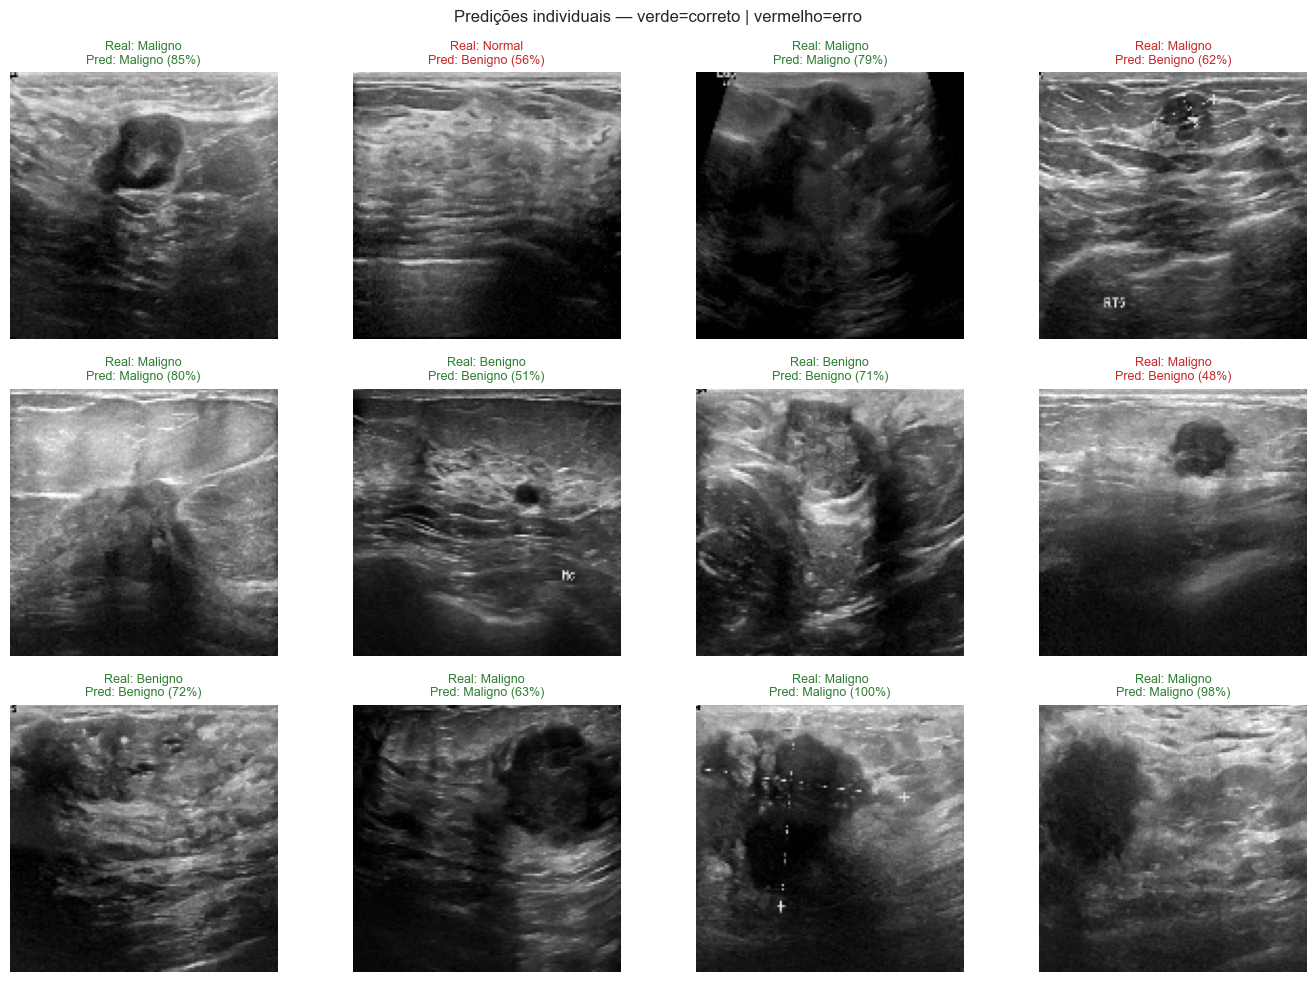

In [12]:
# Pega um batch do conjunto de teste para visualizar
test_imgs_batch, test_labels_batch = next(iter(test_ds))
test_preds_batch = model.predict(test_imgs_batch, verbose=0)

n_show = min(12, len(test_imgs_batch))
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for i, ax in enumerate(axes.flatten()):
    if i >= n_show:
        ax.axis('off')
        continue
    img        = test_imgs_batch[i].numpy()
    true_idx   = int(np.argmax(test_labels_batch[i].numpy()))
    pred_idx   = int(np.argmax(test_preds_batch[i]))
    confidence = float(test_preds_batch[i][pred_idx])

    ax.imshow(img)
    correct = true_idx == pred_idx
    color   = '#2e7d32' if correct else '#c62828'
    title   = (
        f'Real: {CLASSES_PT[true_idx]}\n'
        f'Pred: {CLASSES_PT[pred_idx]} ({confidence:.0%})'
    )
    ax.set_title(title, fontsize=9, color=color)
    ax.axis('off')

plt.suptitle('Predições individuais — verde=correto | vermelho=erro', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/20_cnn_predicoes.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
model.save('../models/cnn_mobilenetv2.keras')
print('Modelo CNN salvo em models/cnn_mobilenetv2.keras')

Modelo CNN salvo em models/cnn_mobilenetv2.keras


## 8. Discussão crítica dos resultados

### O que o modelo faz?
A CNN recebe uma imagem de ultrassonografia de mama e produz um **score de probabilidade** para cada classe (Benigno, Maligno, Normal). O médico receberia algo como:
> *"Probabilidade de malignidade: 87%"*

### Vantagens da abordagem
| Aspecto | Detalhe |
|---|---|
| **Transfer Learning** | Contorna a escassez de dados médicos aproveitando conhecimento de 1.4M imagens |
| **Data Augmentation** | Reduz overfitting ao criar variações realistas de posição e zoom |
| **Fine-tuning progressivo** | Evita catastrophic forgetting ao usar LR 100× menor na fase 2 |
| **Classificação 3 classes** | Inclui a classe "Normal", mais útil clinicamente do que binário puro |

### Limitações e cuidados

1. **Tamanho do dataset:** 780 imagens é insuficiente para aplicação clínica real. Hospitais trabalham com dezenas de milhares de exames.
2. **Generalização:** o modelo foi treinado em imagens de uma única instituição. Equipamentos e técnicas de ultrassom variam — o modelo pode performar pior em imagens de outros hospitais.
3. **Classe normal sub-representada:** apenas 133 imagens normais contra 437 benignas. Um modelo de produção precisaria de balanceamento mais cuidadoso.
4. **Ausência de segmentação:** o modelo recebe a imagem inteira, não a região de interesse. Usar as máscaras de segmentação disponíveis no dataset poderia melhorar o desempenho.

### Complementaridade com o modelo ML

Os dois sistemas — CNN em imagens e Random Forest em dados estruturados — são **complementares**:
- A CNN captura informação espacial e de textura das imagens
- O Random Forest captura relações entre medidas quantitativas das biópsias

Um sistema clínico robusto combinaria ambos em um **modelo ensemble**, aumentando a confiança do diagnóstico.

### O médico sempre tem a palavra final

Qualquer predição deve ser apresentada como **ferramenta de apoio à triagem**, nunca como diagnóstico definitivo. O papel do sistema é:
- Priorizar casos de alta probabilidade de malignidade na fila de atendimento
- Sinalizar casos que merecem atenção imediata
- Reduzir o tempo necessário para revisão de exames de baixo risco